In [1]:
# load the clean dataset
import pandas as pd

df_clean = pd.read_parquet(r"C:\Users\zeid9\Documents\Scalable-MLOps-Pipeline-for-Credit-Risk-Prediction\data\df_clean.parquet")

In [2]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  32581 non-null  int64  
 1   income               32581 non-null  int64  
 2   home_status          32581 non-null  object 
 3   emp_years            32581 non-null  float64
 4   loan_intent          32581 non-null  object 
 5   loan_grade           32581 non-null  object 
 6   loan_amount          32581 non-null  int64  
 7   loan_int_rate        32581 non-null  float64
 8   loan_status          32581 non-null  int64  
 9   loan_percent_income  32581 non-null  float64
 10  credit_default       32581 non-null  object 
 11  credit_history       32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [3]:
# Map 'Y' to 1 and 'N' to 0 in the 'credit_default' column
df_clean['credit_default'] = df_clean['credit_default'].map({'Y': 1, 'N': 0})

In [4]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Define feature columns
cat_cols = ['home_status', 'loan_intent', 'loan_grade']
num_cols = ['income', 'emp_years', 'loan_amount',
            'loan_int_rate', 'loan_status', 'loan_percent_income',
            'credit_history']

# Define input and target
X = df_clean[cat_cols + num_cols]
y = df_clean['credit_default']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Define preprocessing for columns
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])

# Define full pipeline with preprocessing, SMOTE, and model
rf_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(n_estimators= 1000, random_state=42))
])

# Fit the pipeline on training data
rf_pipeline.fit(X_train, y_train)

# Make predictions
y_pred = rf_pipeline.predict(X_test)


In [70]:
from sklearn.metrics import precision_recall_curve, f1_score, accuracy_score, confusion_matrix, roc_auc_score
# Accuracy
print("Accuracy Score:", accuracy_score(y_test, y_pred))

# Evaluate
print(classification_report(y_test, y_pred))

# Confusion matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ROC AUC Score
print("ROC AUC Score:", roc_auc_score(y_test, y_pred))

Accuracy Score: 0.8284486727021636
              precision    recall  f1-score   support

           0       0.95      0.83      0.89      5368
           1       0.51      0.80      0.62      1149

    accuracy                           0.83      6517
   macro avg       0.73      0.82      0.76      6517
weighted avg       0.87      0.83      0.84      6517


Confusion Matrix:
 [[4480  888]
 [ 230  919]]
ROC AUC Score: 0.8172005982004698


## Tunning the model using GridSearchCV

In [6]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np
import time

# Define hyperparameter grid
param_grid = {
    'classifier__max_features': np.arange(1, 11, 1),
    'classifier__n_estimators': np.arange(400, 500, 5),
    'classifier__class_weight': ['balanced'],
    'classifier__max_depth': [8],
    'classifier__min_samples_split': [15],
    'classifier__min_samples_leaf': [1]
}

# Grid Search
grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid, # param_grid for GSCV and parameter_distribution for RSCV
    cv=5,
    #n_iter=10, # only work RSCV
    scoring='recall',  # prioritize recall due to imbalanced data
    n_jobs=-1,
    verbose=2,
    #random_state=42 # only work RSCV
)
# ETA calculation
start = time.time()
# Fit on the original X_train and y_train (not resampled)
grid.fit(X_train, y_train)

print(f"\nTraining completed in {(time.time() - start)/60:.2f} minutes.")


Fitting 5 folds for each of 200 candidates, totalling 1000 fits

Training completed in 73.62 minutes.


In [7]:
print("The best parameters are %s with a score of %0.2f"
      % (grid.best_params_, grid.best_score_))

The best parameters are {'classifier__class_weight': 'balanced', 'classifier__max_depth': 8, 'classifier__max_features': np.int64(5), 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 15, 'classifier__n_estimators': np.int64(405)} with a score of 0.99


In [8]:

import pandas as pd

grid_results = pd.concat(
    [pd.DataFrame(grid.cv_results_["params"]),
     pd.DataFrame(grid.cv_results_["mean_test_score"], 
                  columns=["Recall"])],axis=1)
grid_results

,classifier__class_weight,classifier__max_depth,classifier__max_features,classifier__min_samples_leaf,classifier__min_samples_split,classifier__n_estimators,Recall
0,balanced,8,1,1,15,400,0.971713
1,balanced,8,1,1,15,405,0.971495
2,balanced,8,1,1,15,410,0.969755
3,balanced,8,1,1,15,415,0.969102
4,balanced,8,1,1,15,420,0.967797
...,...,...,...,...,...,...,...
195,balanced,8,10,1,15,475,0.988251
196,balanced,8,10,1,15,480,0.988251
197,balanced,8,10,1,15,485,0.988251
198,balanced,8,10,1,15,490,0.988251


In [9]:
selected_grid_var =grid_results[['classifier__max_features', 'classifier__n_estimators', 'Recall']]
grid_contour = selected_grid_var.groupby(
    ['classifier__max_features', 'classifier__n_estimators']
).mean()

grid_contour_expanded = grid_contour.unstack(level='classifier__n_estimators')
grid_contour_expanded

Recall                                          \
classifier__n_estimators       400       405       410       415       420   
classifier__max_features                                                     
1                         0.971713  0.971495  0.969755  0.969102  0.967797   
2                         0.990426  0.990426  0.990426  0.990426  0.990208   
3                         0.991514  0.991296  0.991296  0.991514  0.991514   
4                         0.992602  0.992602  0.992602  0.992384  0.992384   
5                         0.994343  0.994560  0.994343  0.994343  0.994125   
6                         0.994560  0.994343  0.994343  0.994125  0.994125   
7                         0.993908  0.994125  0.993908  0.993908  0.994125   
8                         0.992167  0.991949  0.992167  0.991949  0.992167   
9                         0.990427  0.990645  0.990645  0.990645  0.990645   
10                        0.987816  0.987599  0.987816  0.987816  0.987816   

                                                                            \
classifier__n_estimators       425       430       435       440       445   
classifier__max_features                                                     
1                         0.968885  0.969102  0.969972  0.970189  0.970842   
2                         0.989990  0.989773  0.989337  0.989773  0.989773   
3                         0.991514  0.991731  0.991949  0.991949  0.991731   
4                         0.992602  0.992602  0.992602  0.992819  0.992819   
5                         0.994343  0.994560  0.994560  0.994343  0.994560   
6                         0.993907  0.993907  0.993907  0.993907  0.994125   
7                         0.993908  0.993908  0.993908  0.993908  0.993908   
8                         0.992167  0.991949  0.992167  0.992167  0.992167   
9                         0.990427  0.990427  0.990862  0.990645  0.990645   
10                        0.988034  0.988034  0.988034  0.987816  0.988034   

                                                                            \
classifier__n_estimators       450       455       460       465       470   
classifier__max_features                                                     
1                         0.970189  0.969319  0.968232  0.967144  0.968667   
2                         0.989337  0.989773  0.989773  0.990426  0.989337   
3                         0.991731  0.991949  0.991731  0.991514  0.991514   
4                         0.992819  0.992819  0.992819  0.992819  0.992819   
5                         0.994560  0.994560  0.994560  0.994343  0.994560   
6                         0.994125  0.994125  0.994125  0.994125  0.994125   
7                         0.993908  0.993908  0.993908  0.993908  0.993908   
8                         0.992167  0.992167  0.992167  0.991949  0.992167   
9                         0.990645  0.990645  0.990427  0.990427  0.990427   
10                        0.988034  0.988034  0.988251  0.988251  0.988686   

                                                                            
classifier__n_estimators       475       480       485       490       495  
classifier__max_features                                                    
1                         0.967144  0.968667  0.967143  0.968667  0.969755  
2                         0.989338  0.989555  0.989338  0.989120  0.989338  
3                         0.991514  0.991514  0.991514  0.991514  0.991296  
4                         0.992819  0.992819  0.992819  0.992819  0.992819  
5                         0.994560  0.994560  0.994560  0.994560  0.994560  
6                         0.994343  0.994125  0.994343  0.994560  0.994560  
7                         0.993908  0.993908  0.993908  0.993908  0.993908  
8                         0.992167  0.992167  0.991949  0.991949  0.991949  
9                         0.990427  0.990427  0.990427  0.990209  0.990209  
10                        0.988251  0.988251  0.988251  0.9

In [10]:

x = grid_contour_expanded.columns.levels[1].values
y = grid_contour_expanded.index.values
z = grid_contour_expanded.values

In [11]:

import plotly.graph_objects as go

# x = n_estimators (columns)
# y = max_features (rows)
# z = Recall

fig = go.Figure(data=[go.Surface(z=z, x=x, y=y)])

fig.update_layout(
    title='Hyperparameter Tuning: Accuracy by n_estimators & max_features',
    scene=dict(
        xaxis=dict(title='n_estimators'),
        yaxis=dict(title='max_features'),
        zaxis=dict(title='Recall'),
    ),
    autosize=False,
    width=800,
    height=800,
    margin=dict(l=65, r=50, b=65, t=90)
)

fig.show()


# Model after tuning

In [12]:
# Define full pipeline with preprocessing, SMOTE, and model using the best parameters after tunning
tuned_rf_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(
        max_features=5,
        n_estimators= 405,
        class_weight='balanced',
        max_depth=8,
        min_samples_split=15,
        min_samples_leaf=1,
        random_state=42)
        )
])

# Fit the pipeline on training data
tuned_rf_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_tuned = tuned_rf_pipeline.predict(X_test)

In [13]:
# Accuracy
print("Accuracy Score:", accuracy_score(y_test, y_pred_tuned))

# Evaluate
print(classification_report(y_test, y_pred_tuned))

# Confusion matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_tuned))

# ROC AUC Score
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_tuned))

Accuracy Score: 0.8279883381924198
              precision    recall  f1-score   support

           0       1.00      0.79      0.88      5368
           1       0.51      1.00      0.67      1149

    accuracy                           0.83      6517
   macro avg       0.75      0.89      0.78      6517
weighted avg       0.91      0.83      0.85      6517


Confusion Matrix:
 [[4252 1116]
 [   5 1144]]
ROC AUC Score: 0.8938748655929668


In [68]:
import joblib
from datetime import datetime
from sklearn.metrics import recall_score

# Define your model version and recall score
model_version = 3
recall_score = recall_score(y_test, tuned_rf_pipeline.predict(X_test))
model_type = 'rf'    
today = datetime.today().strftime('%Y-%m-%d')

# Format the filename
filename = f"{model_type}_v{model_version}_recall{int(recall_score * 100)}_{today}.pkl"

# Define save directory (you can customize the folder)
save_path = f"C:/Users/zeid9/Documents/Scalable-MLOps-Pipeline-for-Credit-Risk-Prediction/models/{filename}"

# Save the model
joblib.dump(tuned_rf_pipeline, save_path)

print(f"Model saved to: {save_path}")


Model saved to: C:/Users/zeid9/Documents/Scalable-MLOps-Pipeline-for-Credit-Risk-Prediction/models/rf_v3_recall99_2025-07-17.pkl


In [26]:
# Get predicted probabilities for class 1
y_probs = tuned_rf_pipeline.predict_proba(X_test)[:, 1]

# Set custom threshold (e.g., 0.3)
custom_threshold = 0.7
y_pred_custom = (y_probs >= custom_threshold).astype(int)

# Accuracy
print("Accuracy Score:", accuracy_score(y_test, y_pred_custom))

# Evaluate
print(classification_report(y_test, y_pred_custom))

# Confusion matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_custom))

# ROC AUC Score
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_custom))


Accuracy Score: 0.8281417830290011
              precision    recall  f1-score   support

           0       0.95      0.83      0.89      5368
           1       0.51      0.81      0.63      1149

    accuracy                           0.83      6517
   macro avg       0.73      0.82      0.76      6517
weighted avg       0.88      0.83      0.84      6517


Confusion Matrix:
 [[4462  906]
 [ 214  935]]
ROC AUC Score: 0.8224865722672082


In [67]:
# Example input sample in original form (dict or DataFrame)
sample = {
    'income': 6000,
    'home_status': 'RENT',
    'emp_years': 1,
    'loan_intent': 'MEDICAL',
    'loan_grade': 'D',
    'loan_amount': 10000,
    'loan_int_rate': 2.14,
    'loan_status': 1,
    'loan_percent_income': 12.8,
    'credit_history': 6
}

import pandas as pd
input_df = pd.DataFrame([sample])

# Get predicted probabilities
probs = tuned_rf_pipeline.predict_proba(input_df)

# Manually set your threshold
threshold = 0.68  # 

# Get the probability for class 1 (positive class)
prob_class_1 = probs[:, 1]

# Apply threshold
custom_prediction = (prob_class_1 > threshold).astype(int)

# Print result
print(f"Default Threshold ({threshold}) Prediction:", custom_prediction[0])
print(f"Probability of Default (class 1): {prob_class_1[0] * 100:.2f}%")

# Interpretive message
if custom_prediction[0] == 1:
    print("Prediction: YES - Likely to Default")
else:
    print("Prediction: NO - Unlikely to Default")


Default Threshold (0.68) Prediction: 0
Probability of Default (class 1): 42.49%
Prediction: NO - Unlikely to Default


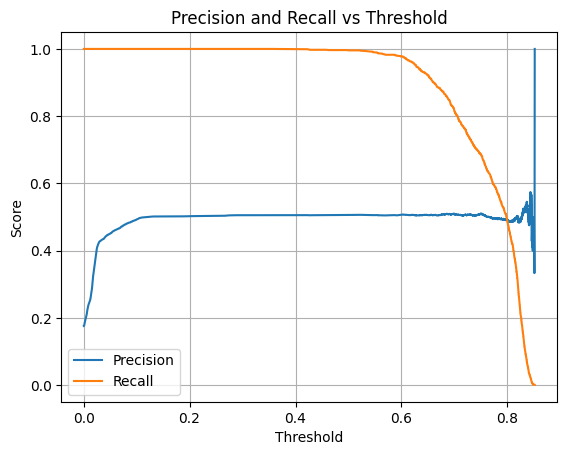

In [30]:

y_proba = tuned_rf_pipeline.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Plot PR curve
import matplotlib.pyplot as plt

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Threshold')
plt.legend()
plt.grid(True)
plt.show()


In [37]:
y_proba

array([0.0050831 , 0.71664373, 0.02245603, ..., 0.78458259, 0.01067777,
       0.01400275], shape=(6517,))

In [38]:
y_test

19944    0
1230     0
8660     0
20787    0
15698    0
        ..
2089     0
23257    0
6322     0
2933     0
10919    0
Name: credit_default, Length: 6517, dtype: int64